In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

from lightglue import SuperPoint
from lightglue import LightGlue
from lightglue.utils import load_image
from lightglue.utils import rbd

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


Device: cuda


In [3]:
DATASET_ROOT = Path(
    r"E:\Nordland Dataset\nordland-part-2020\nordland-part-2020"
)

SUMMER_DIR = DATASET_ROOT / "summer"
WINTER_DIR = DATASET_ROOT / "winter"

In [4]:
summer_images = sorted(
    list(SUMMER_DIR.glob("*.png"))
)

winter_images = sorted(
    list(WINTER_DIR.glob("*.png"))
)

print(
    "Summer Images:",
    len(summer_images)
)

print(
    "Winter Images:",
    len(winter_images)
)

Summer Images: 1750
Winter Images: 1750


In [5]:
extractor = (
    SuperPoint(
        max_num_keypoints=4096
    )
    .eval()
    .to(device)
)

matcher = (
    LightGlue(
        features="superpoint"
    )
    .eval()
    .to(device)
)

print("Models Loaded")


Models Loaded


In [6]:
MATCH_DIR = Path(
    "outputs/matches"
)

MATCH_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output Folder Ready")

Output Folder Ready


In [16]:
def match_pair(
    summer_img,
    winter_img
):

    image0 = load_image(
        str(summer_img)
    ).to(device)

    image1 = load_image(
        str(winter_img)
    ).to(device)

    feats0 = extractor.extract(image0)
    feats1 = extractor.extract(image1)

    matches01 = matcher({
        "image0": feats0,
        "image1": feats1
    })

    feats0, feats1, matches01 = [
        rbd(x)
        for x in [
            feats0,
            feats1,
            matches01
        ]
    ]

    matches = matches01["matches"]

    if len(matches) < 10:
        raise Exception(
            "Too few matches"
        )

    points0 = (
        feats0["keypoints"]
        [matches[:,0]]
        .cpu()
        .numpy()
    )

    points1 = (
        feats1["keypoints"]
        [matches[:,1]]
        .cpu()
        .numpy()
    )

    H, mask = cv2.findHomography(
        points0,
        points1,
        cv2.USAC_MAGSAC,
        3.0
    )

    if H is None:
        raise Exception(
            "Homography Failed"
        )

    inliers = int(mask.sum())

    ratio = (
        inliers /
        len(mask)
    )

    return {
        "H": H,
        "mask": mask,
        "points0": points0,
        "points1": points1,
        "matches": matches,
        "inliers": inliers,
        "ratio": ratio
    }

In [17]:
idx = 1100

result = match_pair(
    summer_images[idx],
    winter_images[idx]
)

print(
    "Inliers:",
    result["inliers"]
)

print(
    "Ratio:",
    result["ratio"]
)

Inliers: 77
Ratio: 0.41621621621621624


In [18]:
def draw_matches(
    summer_img,
    winter_img,
    result
):

    mask = (
        result["mask"]
        .ravel()
        .astype(bool)
    )

    pts0 = (
        result["points0"]
        [mask]
    )

    pts1 = (
        result["points1"]
        [mask]
    )

    img1 = cv2.imread(
        str(summer_img)
    )

    img2 = cv2.imread(
        str(winter_img)
    )

    kp1 = [
        cv2.KeyPoint(
            float(x),
            float(y),
            1
        )
        for x,y in pts0
    ]

    kp2 = [
        cv2.KeyPoint(
            float(x),
            float(y),
            1
        )
        for x,y in pts1
    ]

    matches = [
        cv2.DMatch(
            i,
            i,
            0
        )
        for i in range(
            len(pts0)
        )
    ]

    vis = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return vis

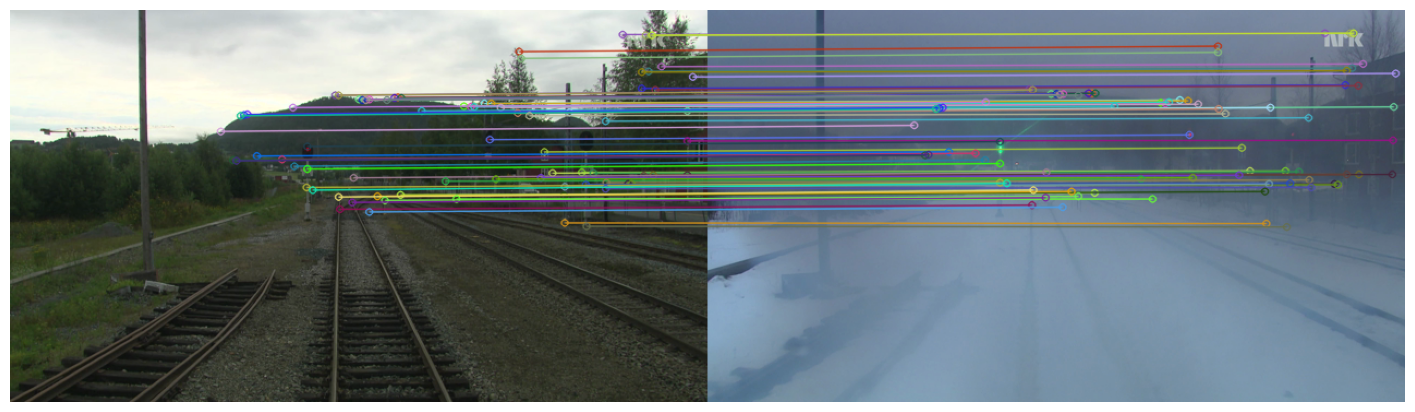

In [19]:
vis = draw_matches(
    summer_images[1100],
    winter_images[1100],
    result
)

plt.figure(figsize=(18,8))

plt.imshow(
    cv2.cvtColor(
        vis,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.show()

In [20]:
selected_frames = [
    250,
    625,
    1600,
    1625,
    1650
]

In [21]:
results_table = []

for idx in selected_frames:

    try:

        result = match_pair(
            summer_images[idx],
            winter_images[idx]
        )

        vis = draw_matches(
            summer_images[idx],
            winter_images[idx],
            result
        )

        cv2.imwrite(
            str(
                MATCH_DIR /
                f"match_{idx}.png"
            ),
            vis
        )

        results_table.append([
            idx,
            result["inliers"],
            round(
                result["ratio"],
                3
            )
        ])

        print(
            f"Saved Frame {idx}"
        )

    except Exception as e:

        print(
            f"Failed {idx}",
            e
        )
        

Saved Frame 250
Saved Frame 625
Saved Frame 1600
Saved Frame 1625
Saved Frame 1650


In [22]:
df = pd.DataFrame(
    results_table,
    columns=[
        "Frame",
        "Inliers",
        "Inlier Ratio"
    ]
)

df

,Frame,Inliers,Inlier Ratio
0,250,95,0.779
1,625,125,0.758
2,1600,65,0.774
3,1625,16,0.941
4,1650,21,0.875


In [14]:
df.to_csv(
    "outputs/match_results.csv",
    index=False
)

print(
    "Match Results Saved"
)

Match Results Saved
